# v8 Analysis — 17 Patients (10 D1 + 7 New), 4 Models

| # | Model | Checkpoint | Training Data |
|---|---|---|---|
| 1 | **baseline** | baseline_best_model.pth | DESS only (no PD fine-tuning) |
| 2 | **v7_realPD** | run_v7_realPD/ckpt_best.pth | Real PD only (15 patients) |
| 3 | **run_002_v2** | run_002_v2/ckpt_best.pth | Pseudo PD only (RegGAN output) |
| 4 | **v7_mixed** | run_v7_mixed/ckpt_best.pth | Real PD (15 patients) + fake PD |

GT masks: `PD-segmentations-final/` (D1) + `Downloads/segmentations/` (new 7)

In [1]:
import os, re, glob
import numpy as np
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"
RES  = f"{BASE}/results/final_results"

PD_DIR     = "/Users/anshikabajpai/Desktop/AImed-lab/IU-Dess-dataset/iu-dataset/pd-files"
GT_DIR_D1  = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final"
GT_DIR_NEW = "/Users/anshikabajpai/Downloads/segmentations"

PRED_BASELINE_DIR  = f"{RES}/real_pd_predictions_v8_baseline"
PRED_REALPD_DIR    = f"{RES}/real_pd_predictions_v8_realPD"
PRED_PSEUDOPD_DIR  = f"{RES}/real_pd_predictions_v8_pseudoPD"
PRED_MIXED_DIR     = f"{RES}/real_pd_predictions_v8_mixed"

D1_PATIENTS = [
    "AC0D5A4D78B628", "AC0D7BF72F7712", "AC0D3459553205", "AC14D3737C0482",
    "AC19E7C19827FF", "AC149BC218E75C", "AC111633B463BB", "AC13300201B926",
    "AC12026D14291F", "AC13637DA25399",
]
NEW_PATIENTS = [
    "AC000550763509", "AC005135D3495B", "AC04433E37DB66", "AC056ADCE8BE28",
    "AC07607B9E5295", "AC0D1A9818A6FC", "AC0F11041F5180",
]
ALL_PATIENTS = D1_PATIENTS + NEW_PATIENTS
print(f"Total patients: {len(ALL_PATIENTS)}  (D1={len(D1_PATIENTS)}, new={len(NEW_PATIENTS)})")

Total patients: 17  (D1=10, new=7)


In [3]:
# ── Helpers ────────────────────────────────────────────────────────────────
def get_pid(fname):
    m = re.match(r"(AC[A-F0-9]+)", os.path.basename(fname), re.IGNORECASE)
    return m.group(1) if m else None

def patients_in_dir(directory, pattern="*.nii.gz"):
    files = glob.glob(os.path.join(directory, pattern))
    return {get_pid(f): f for f in files if get_pid(f)}

def load_nrrd_binary(path):
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    if arr.ndim == 4:
        arr = (arr.max(axis=0) > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        try:
            comp = sitk.VectorIndexSelectionCast(img, 0)
            out.CopyInformation(comp)
        except Exception:
            out.SetSpacing(img.GetSpacing()[:3]); out.SetOrigin(img.GetOrigin()[:3])
            out.SetDirection(img.GetDirection()[:9])
    else:
        arr = (arr > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        out.CopyInformation(img)
    try: out = sitk.DICOMOrient(out, "RAS")
    except Exception: pass
    sp  = out.GetSpacing()
    arr = sitk.GetArrayFromImage(out).astype(np.float32).transpose(2, 1, 0)
    fa, fs = float(sp[1]) / min(sp[1], sp[2]), float(sp[2]) / min(sp[1], sp[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384/n_A, 384/n_S), order=0)
    return (arr > 0.5).astype(bool)

def preprocess_pd_image(path):
    img   = nib.as_closest_canonical(nib.load(path))
    arr   = img.get_fdata().astype(np.float32)
    zooms = img.header.get_zooms()[:3]
    fa, fs = float(zooms[1]) / min(zooms[1], zooms[2]), float(zooms[2]) / min(zooms[1], zooms[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=3)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384/n_A, 384/n_S), order=3)
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    return (np.clip(arr, lo, hi) - lo) / (hi - lo + 1e-8)

def load_vol(path): return np.asarray(nib.load(path).get_fdata())
def merge_meniscus(pred): return (pred > 0).astype(bool)
def dice_score(pred_bin, gt_bin):
    inter = (pred_bin & gt_bin).sum(); denom = pred_bin.sum() + gt_bin.sum()
    return float(2 * inter / denom) if denom > 0 else 1.0
def best_class_dice(pred_5class, gt_bin):
    best_d, best_c = -1.0, -1
    for c in range(1, 5):
        d = dice_score((pred_5class == c), gt_bin)
        if d > best_d: best_d, best_c = d, c
    return best_d, best_c

In [4]:
# ── Find GT masks ───────────────────────────────────────────────────────────
gt_masks = {}
for pid in ALL_PATIENTS:
    hits = glob.glob(os.path.join(GT_DIR_D1,  f"{pid}*.seg.nrrd")) or            glob.glob(os.path.join(GT_DIR_NEW, f"{pid}*.seg.nrrd"))
    if hits: gt_masks[pid] = hits[0]
    else: print(f"WARNING: No GT mask for {pid}")
print(f"GT masks found: {len(gt_masks)}/17")

baseline_preds = patients_in_dir(PRED_BASELINE_DIR)
realpd_preds   = patients_in_dir(PRED_REALPD_DIR)
pseudopd_preds = patients_in_dir(PRED_PSEUDOPD_DIR)
mixed_preds    = patients_in_dir(PRED_MIXED_DIR)
print(f"Baseline preds : {len(baseline_preds)}")
print(f"v7_realPD preds: {len(realpd_preds)}")
print(f"run_002_v2 preds: {len(pseudopd_preds)}")
print(f"v7_mixed preds : {len(mixed_preds)}")

GT masks found: 17/17
Baseline preds : 17
v7_realPD preds: 17
run_002_v2 preds: 17
v7_mixed preds : 17


In [5]:
# ── Compute Dice ────────────────────────────────────────────────────────────
results = []

for pid in ALL_PATIENTS:
    if pid not in gt_masks:
        print(f"SKIP {pid} — no GT mask"); continue

    gt_bin = load_nrrd_binary(gt_masks[pid])
    row = {"patient": pid, "cohort": "D1" if pid in D1_PATIENTS else "new", "_gt": gt_bin}

    # 1. Baseline (5-class)
    if pid in baseline_preds:
        pred_b = load_vol(baseline_preds[pid]).astype(np.int16)
        d_b, best_c = best_class_dice(pred_b, gt_bin)
        row["dice_baseline"] = d_b; row["baseline_class"] = best_c
        row["_pred_baseline"] = pred_b; row["_pred_baseline_bin"] = (pred_b == best_c)
    else:
        row["dice_baseline"] = float("nan"); row["_pred_baseline"] = None

    # 2. v7_realPD (3-class)
    if pid in realpd_preds:
        pred_r = load_vol(realpd_preds[pid])
        row["dice_v7_realPD"] = dice_score(merge_meniscus(pred_r), gt_bin)
        row["_pred_realpd"] = pred_r
    else:
        row["dice_v7_realPD"] = float("nan"); row["_pred_realpd"] = None

    # 3. run_002_v2 pseudo PD (3-class)
    if pid in pseudopd_preds:
        pred_p = load_vol(pseudopd_preds[pid])
        row["dice_run_002_v2"] = dice_score(merge_meniscus(pred_p), gt_bin)
        row["_pred_pseudopd"] = pred_p
    else:
        row["dice_run_002_v2"] = float("nan"); row["_pred_pseudopd"] = None

    # 4. v7_mixed (3-class)
    if pid in mixed_preds:
        pred_m = load_vol(mixed_preds[pid])
        row["dice_v7_mixed"] = dice_score(merge_meniscus(pred_m), gt_bin)
        row["_pred_mixed"] = pred_m
    else:
        row["dice_v7_mixed"] = float("nan"); row["_pred_mixed"] = None

    results.append(row)
    print(f"{pid} ({row['cohort']})  "
          f"baseline={row['dice_baseline']:.3f}  "
          f"v7_realPD={row['dice_v7_realPD']:.3f}  "
          f"run_002_v2={row['dice_run_002_v2']:.3f}  "
          f"v7_mixed={row['dice_v7_mixed']:.3f}")

run_names = ["baseline", "v7_realPD", "run_002_v2", "v7_mixed"]
means_all, means_d1, means_new = {}, {}, {}
for rn in run_names:
    key = f"dice_{rn}"
    all_v = [r[key] for r in results if not np.isnan(r.get(key, float("nan")))]
    d1_v  = [r[key] for r in results if r["cohort"]=="D1"  and not np.isnan(r.get(key, float("nan")))]
    new_v = [r[key] for r in results if r["cohort"]=="new" and not np.isnan(r.get(key, float("nan")))]
    means_all[rn]=np.mean(all_v) if all_v else float("nan")
    means_d1[rn] =np.mean(d1_v)  if d1_v  else float("nan")
    means_new[rn]=np.mean(new_v)  if new_v  else float("nan")

print("\nMEAN Dice (all 17):", {k: f"{v:.4f}" for k,v in means_all.items()})
print("MEAN Dice (D1  10):", {k: f"{v:.4f}" for k,v in means_d1.items()})
print("MEAN Dice (new  7):", {k: f"{v:.4f}" for k,v in means_new.items()})

AC0D5A4D78B628 (D1)  baseline=0.000  v7_realPD=0.370  run_002_v2=0.601  v7_mixed=0.709
AC0D7BF72F7712 (D1)  baseline=0.000  v7_realPD=0.487  run_002_v2=0.696  v7_mixed=0.777
AC0D3459553205 (D1)  baseline=0.000  v7_realPD=0.409  run_002_v2=0.659  v7_mixed=0.725
AC14D3737C0482 (D1)  baseline=0.000  v7_realPD=0.481  run_002_v2=0.637  v7_mixed=0.791
AC19E7C19827FF (D1)  baseline=0.000  v7_realPD=0.562  run_002_v2=0.705  v7_mixed=0.802
AC149BC218E75C (D1)  baseline=0.000  v7_realPD=0.456  run_002_v2=0.713  v7_mixed=0.801
AC111633B463BB (D1)  baseline=0.000  v7_realPD=0.517  run_002_v2=0.745  v7_mixed=0.809
AC13300201B926 (D1)  baseline=0.000  v7_realPD=0.447  run_002_v2=0.726  v7_mixed=0.763
AC12026D14291F (D1)  baseline=0.001  v7_realPD=0.507  run_002_v2=0.727  v7_mixed=0.786
AC13637DA25399 (D1)  baseline=0.000  v7_realPD=0.522  run_002_v2=0.741  v7_mixed=0.808
AC000550763509 (new)  baseline=0.000  v7_realPD=0.447  run_002_v2=0.735  v7_mixed=0.809
AC005135D3495B (new)  baseline=0.000  v7_r

In [6]:
# ── Summary table ───────────────────────────────────────────────────────────
header = f"{'Patient':<22} {'Cohort':<6}" + "".join(f"{n:>14}" for n in run_names)
print(header); print("-"*len(header))
for r in results:
    row_str = f"{r['patient']:<22} {r['cohort']:<6}"
    for rn in run_names:
        row_str += f"{r.get(f'dice_{rn}', float('nan')):>14.4f}"
    print(row_str)
print("-"*len(header))
for label, means in [("MEAN all 17", means_all), ("MEAN D1  10", means_d1), ("MEAN new   7", means_new)]:
    print(f"{label:<28}" + "".join(f"{means[rn]:>14.4f}" for rn in run_names))

Patient                Cohort      baseline     v7_realPD    run_002_v2      v7_mixed
-------------------------------------------------------------------------------------
AC0D5A4D78B628         D1            0.0000        0.3700        0.6013        0.7093
AC0D7BF72F7712         D1            0.0000        0.4866        0.6962        0.7771
AC0D3459553205         D1            0.0000        0.4090        0.6590        0.7250
AC14D3737C0482         D1            0.0002        0.4806        0.6375        0.7906
AC19E7C19827FF         D1            0.0000        0.5616        0.7052        0.8025
AC149BC218E75C         D1            0.0000        0.4558        0.7134        0.8009
AC111633B463BB         D1            0.0000        0.5169        0.7449        0.8094
AC13300201B926         D1            0.0000        0.4466        0.7260        0.7626
AC12026D14291F         D1            0.0014        0.5073        0.7272        0.7862
AC13637DA25399         D1            0.0000        0.5

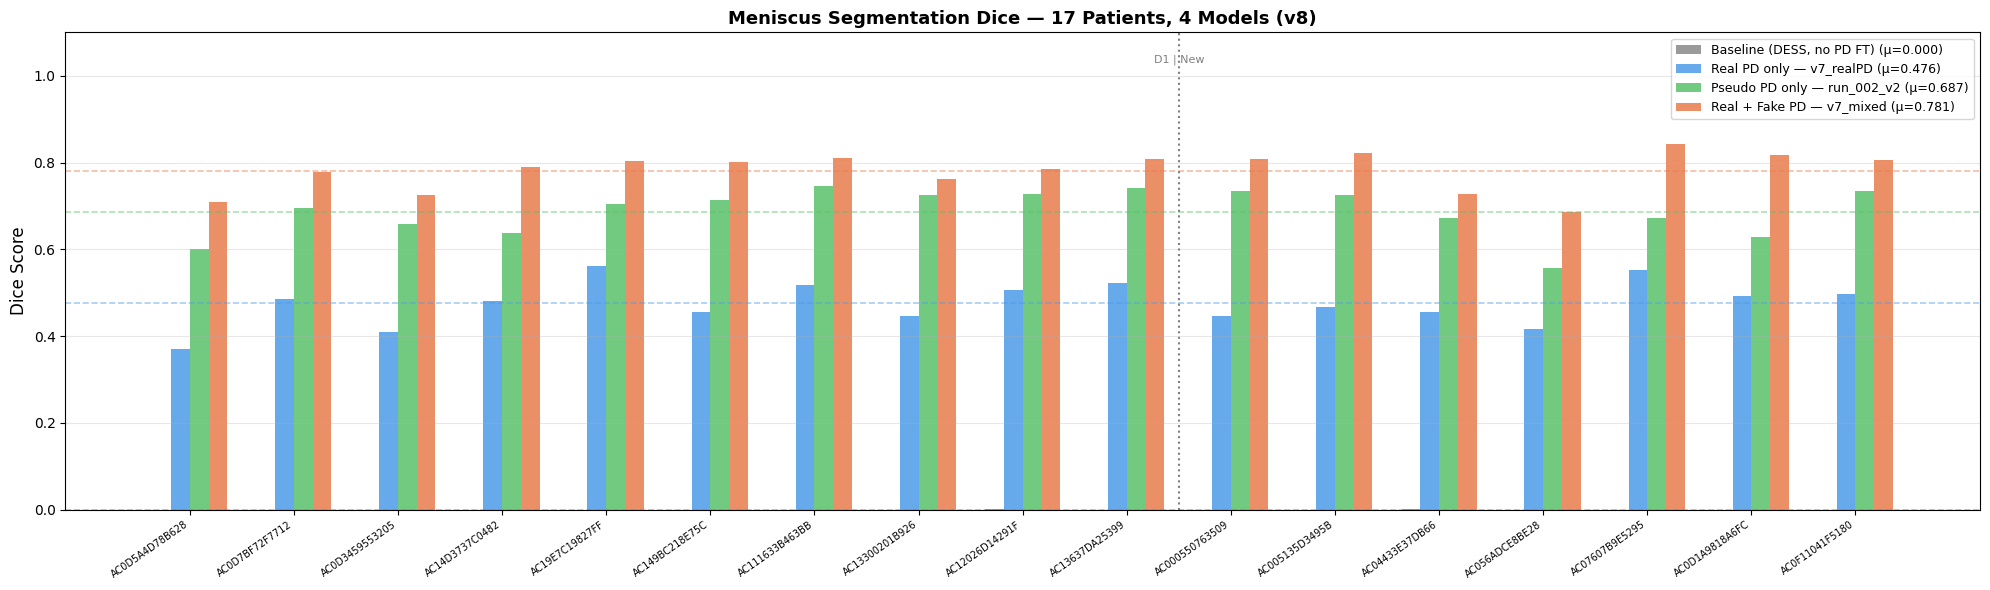

In [7]:
# ── Bar chart ───────────────────────────────────────────────────────────────
COLORS = {
    "baseline":    "#888888",
    "v7_realPD":   "#4C9BE8",
    "run_002_v2":  "#59C16A",
    "v7_mixed":    "#E87B4C",
}
LABELS = {
    "baseline":   "Baseline (DESS, no PD FT)",
    "v7_realPD":  "Real PD only — v7_realPD",
    "run_002_v2": "Pseudo PD only — run_002_v2",
    "v7_mixed":   "Real + Fake PD — v7_mixed",
}

patients = [r["patient"] for r in results]
x = np.arange(len(patients))
w = 0.18
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]

fig, ax = plt.subplots(figsize=(20, 6))
for i, rn in enumerate(run_names):
    dice_vals = [r.get(f"dice_{rn}", float("nan")) for r in results]
    m = means_all[rn]
    ax.bar(x + offsets[i], dice_vals, w,
           label=f"{LABELS[rn]} (μ={m:.3f})", color=COLORS[rn], alpha=0.85)
    ax.axhline(m, color=COLORS[rn], linestyle="--", alpha=0.5, linewidth=1.2)

n_d1 = sum(1 for r in results if r["cohort"] == "D1")
ax.axvline(n_d1 - 0.5, color="grey", linewidth=1.5, linestyle=":")
ax.text(n_d1 - 0.5, 1.03, "D1 | New", ha="center", fontsize=8, color="grey")

ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=35, ha="right", fontsize=7)
ax.set_ylabel("Dice Score", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("Meniscus Segmentation Dice — 17 Patients, 4 Models (v8)", fontweight="bold", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/dice_v8_17patients.png", dpi=150)
plt.show()

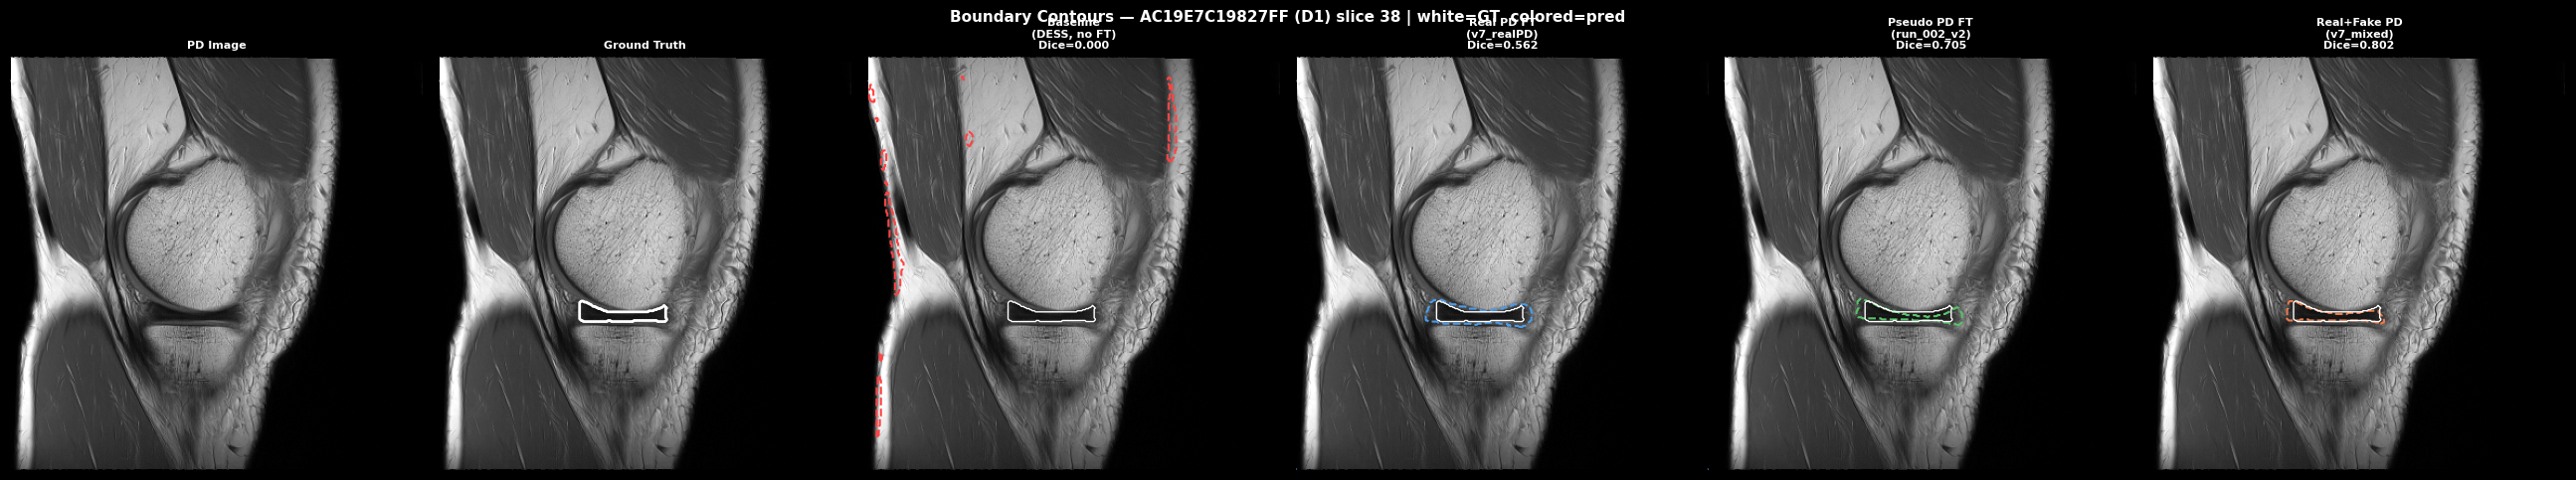

In [8]:
# ── Boundary overlay — best patient ─────────────────────────────────────────
best_pid = max((r["patient"] for r in results),
               key=lambda pid: next(r["_gt"].sum() for r in results if r["patient"]==pid))
r = next(x for x in results if x["patient"]==best_pid)
gt_bin  = r["_gt"]
best_sl = int(np.argmax(gt_bin.sum(axis=(1,2))))

pd_files = glob.glob(os.path.join(PD_DIR, f"{best_pid}*.nii*"))
pd_sl = np.zeros((384,384))
if pd_files:
    pd_vol = preprocess_pd_image(pd_files[0])
    if pd_vol.shape[0] != gt_bin.shape[0]:
        pd_vol = zoom(pd_vol, (gt_bin.shape[0]/pd_vol.shape[0], 1.0, 1.0), order=3)
    pd_sl = pd_vol[best_sl]

fig, axes = plt.subplots(1, 6, figsize=(26, 5), facecolor="black")
titles = ["PD Image","Ground Truth","Baseline\n(DESS, no FT)",
          "Real PD FT\n(v7_realPD)","Pseudo PD FT\n(run_002_v2)","Real+Fake PD\n(v7_mixed)"]
pred_keys  = [None, None, "_pred_baseline", "_pred_realpd", "_pred_pseudopd", "_pred_mixed"]
dice_keys  = [None, None, "dice_baseline", "dice_v7_realPD", "dice_run_002_v2", "dice_v7_mixed"]
contour_cs = [None, None, "#FF4444", "#4C9BE8", "#59C16A", "#E87B4C"]

for ax, title in zip(axes, titles):
    ax.set_facecolor("black")
    ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(title, color="white", fontsize=8, fontweight="bold")
    ax.axis("off")

if gt_bin[best_sl].any():
    axes[1].contour(gt_bin[best_sl].T, levels=[0.5], colors=["#FFFFFF"], linewidths=2)

for ax, pk, dk, cc in zip(axes[2:], pred_keys[2:], dice_keys[2:], contour_cs[2:]):
    pred = r.get(pk)
    if pred is None: continue
    if pk == "_pred_baseline":
        pred_bin = r["_pred_baseline_bin"][best_sl]
    else:
        pred_bin = merge_meniscus(pred)[best_sl]
    if pred_bin.any():
        ax.contour(pred_bin.T, levels=[0.5], colors=[cc], linewidths=1.5, linestyles="dashed")
    if gt_bin[best_sl].any():
        ax.contour(gt_bin[best_sl].T, levels=[0.5], colors=["#FFFFFF"], linewidths=1)
    d = r.get(dk, float("nan"))
    ax.set_title(ax.get_title() + f"\nDice={d:.3f}", color="white", fontsize=8, fontweight="bold")

plt.suptitle(f"Boundary Contours — {best_pid} ({r['cohort']}) slice {best_sl} | white=GT  colored=pred",
             fontsize=11, fontweight="bold", color="white")
plt.tight_layout()
plt.savefig(f"{BASE}/boundary_v8_17patients.png", dpi=150, facecolor="black")
plt.show()

In [9]:
# ── Final summary ───────────────────────────────────────────────────────────
print("="*65)
print("v8 SUMMARY — 17 patients (10 D1 + 7 new), 4 models")
print("="*65)
descs = {
    "baseline":   "Baseline — DESS pre-trained (no PD fine-tuning)",
    "v7_realPD":  "Real PD only — v7_realPD (15 patients)",
    "run_002_v2": "Pseudo PD only — run_002_v2 (RegGAN fake PD)",
    "v7_mixed":   "Real + Fake PD — v7_mixed (15 patients)",
}
base = means_all.get("baseline", float("nan"))
for rn in run_names:
    m = means_all[rn]; delta = m - base; sign = "+" if delta>=0 else ""
    print(f"\n  {descs[rn]}")
    print(f"    Mean Dice (all 17) = {m:.4f}  ({sign}{delta*100:.1f}% vs baseline)")
    print(f"    Mean Dice (D1  10) = {means_d1[rn]:.4f}")
    print(f"    Mean Dice (new  7) = {means_new[rn]:.4f}")

v8 SUMMARY — 17 patients (10 D1 + 7 new), 4 models

  Baseline — DESS pre-trained (no PD fine-tuning)
    Mean Dice (all 17) = 0.0003  (+0.0% vs baseline)
    Mean Dice (D1  10) = 0.0002
    Mean Dice (new  7) = 0.0004

  Real PD only — v7_realPD (15 patients)
    Mean Dice (all 17) = 0.4756  (+47.5% vs baseline)
    Mean Dice (D1  10) = 0.4757
    Mean Dice (new  7) = 0.4754

  Pseudo PD only — run_002_v2 (RegGAN fake PD)
    Mean Dice (all 17) = 0.6870  (+68.7% vs baseline)
    Mean Dice (D1  10) = 0.6952
    Mean Dice (new  7) = 0.6751

  Real + Fake PD — v7_mixed (15 patients)
    Mean Dice (all 17) = 0.7812  (+78.1% vs baseline)
    Mean Dice (D1  10) = 0.7772
    Mean Dice (new  7) = 0.7870
